# 🎫 Smart Ticket Triage — an NLP Co-Pilot for Customer Support

## The problem
A support team receives thousands of messages a day. Humans waste hours **reading, tagging, prioritising and routing** each one, while a *"production is down"* message sits in the same queue as *"please add dark mode"*. Slow triage = angry customers, missed SLAs, burned-out agents.

## What I build
One text-only pipeline that reads a raw ticket and instantly predicts:

| Output | Task type | Why it matters |
|---|---|---|
| **Category** (Billing, Technical, Account Access, Shipping, Refund, Feature Request) | Multi-class NLP classification | Routes the ticket to the right team |
| **Priority** (Low → Critical) | Ordinal classification | Decides who gets answered first |
| **Resolution time** (hours) | Regression | Sets customer expectations / SLA |

…and wraps it in an **interactive triage console** with confidence bars, explanations and a live priority queue.

## Dataset — `triage_tickets_dataset.csv`
6,000 tickets · 9 columns · `ticket_id, created_at, channel, customer_tier, subject, message, category, priority, resolution_hours`.
It is **synthetic** (generated with templates, typos, urgency phrases and ~4% label noise to mimic messy real helpdesk exports), so it is safe to share. The same pipeline works unchanged on a real export (Zendesk, Freshdesk, Kaggle *Customer Support Ticket* datasets) — just keep the column names.

**Level: intermediate** → TF-IDF (word + character n-grams), multi-model comparison, cross-validation, ordinal metrics, regression on a log-target, model explainability, and a deployable UI.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import re, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, mean_absolute_error, r2_score)

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams.update({"figure.dpi":110, "axes.titleweight":"bold"})
SEED = 42

## 1 · Load the data
 insert the dataset ourselves with `pd.read_csv`. **In Colab** a file picker pops up — choose `triage_tickets_dataset.csv`. Locally, keep it next to the notebook.

In [2]:
import os
if not os.path.exists("triage_tickets_dataset.csv"):
    try:                                              # Google Colab → pop-up file picker
        from google.colab import files
        print("📂 Please select triage_tickets_dataset.csv …")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Put triage_tickets_dataset.csv in the same folder as this notebook.")

df = pd.read_csv("triage_tickets_dataset.csv", parse_dates=["created_at"])

# sanity check: make sure this is the right file
need = {"ticket_id","created_at","channel","customer_tier","subject","message","category","priority","resolution_hours"}
missing = need - set(df.columns)
assert not missing, f"Wrong CSV! Missing columns {missing}. Upload 'triage_tickets_dataset.csv' that came with this notebook."
assert set(df.priority) == {"Low","Medium","High","Critical"}, "Unexpected priority values — wrong dataset file?"
print(df.shape)
df.head()

(6000, 9)


,ticket_id,created_at,channel,customer_tier,subject,message,category,priority,resolution_hours
0,TKT-100000,2025-01-01 00:00:00,Email,Free,The app keeps crashing every,"Hello, The ap pkeeps crashing every time I ope...",Technical Issue,Medium,36.1
1,TKT-100001,2025-01-01 02:32:00,Twitter,Free,The refund was credited for,The refund was credited for less than I paid K...,Refund & Return,Medium,30.6
2,TKT-100002,2025-01-01 05:05:00,Web Form,Premium,After the latest update the,Please help quickly. After the latest update t...,Technical Issue,High,8.9
3,TKT-100003,2025-01-01 07:38:00,Email,Enterprise,My account got locked after,"Hi team, My account got locked after several a...",Account Access,Medium,3.7
4,TKT-100004,2025-01-01 10:11:00,Web Form,Standard,My invoice shows an amount,"Just curious, My invoice shows an amount I don...",Billing,Low,12.1


In [3]:
df.info()
print("\nMissing values:\n", df.isna().sum())
df.select_dtypes(exclude=["number","datetime"]).describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         6000 non-null   object        
 1   created_at        6000 non-null   datetime64[ns]
 2   channel           6000 non-null   object        
 3   customer_tier     6000 non-null   object        
 4   subject           6000 non-null   object        
 5   message           6000 non-null   object        
 6   category          6000 non-null   object        
 7   priority          6000 non-null   object        
 8   resolution_hours  6000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 422.0+ KB

Missing values:
 ticket_id           0
created_at          0
channel             0
customer_tier       0
subject             0
message             0
category            0
priority            0
resolution_hours    0
dtype: int6

,count,unique,top,freq
ticket_id,6000,6000,TKT-105983,1
channel,6000,5,Twitter,1246
customer_tier,6000,4,Standard,2093
subject,6000,835,The sync between my phone,295
message,6000,4777,The courier marked my parcel delivered but I n...,15
category,6000,6,Technical Issue,1422
priority,6000,4,Medium,2769


## 2 · Explore — what does a support queue look like?

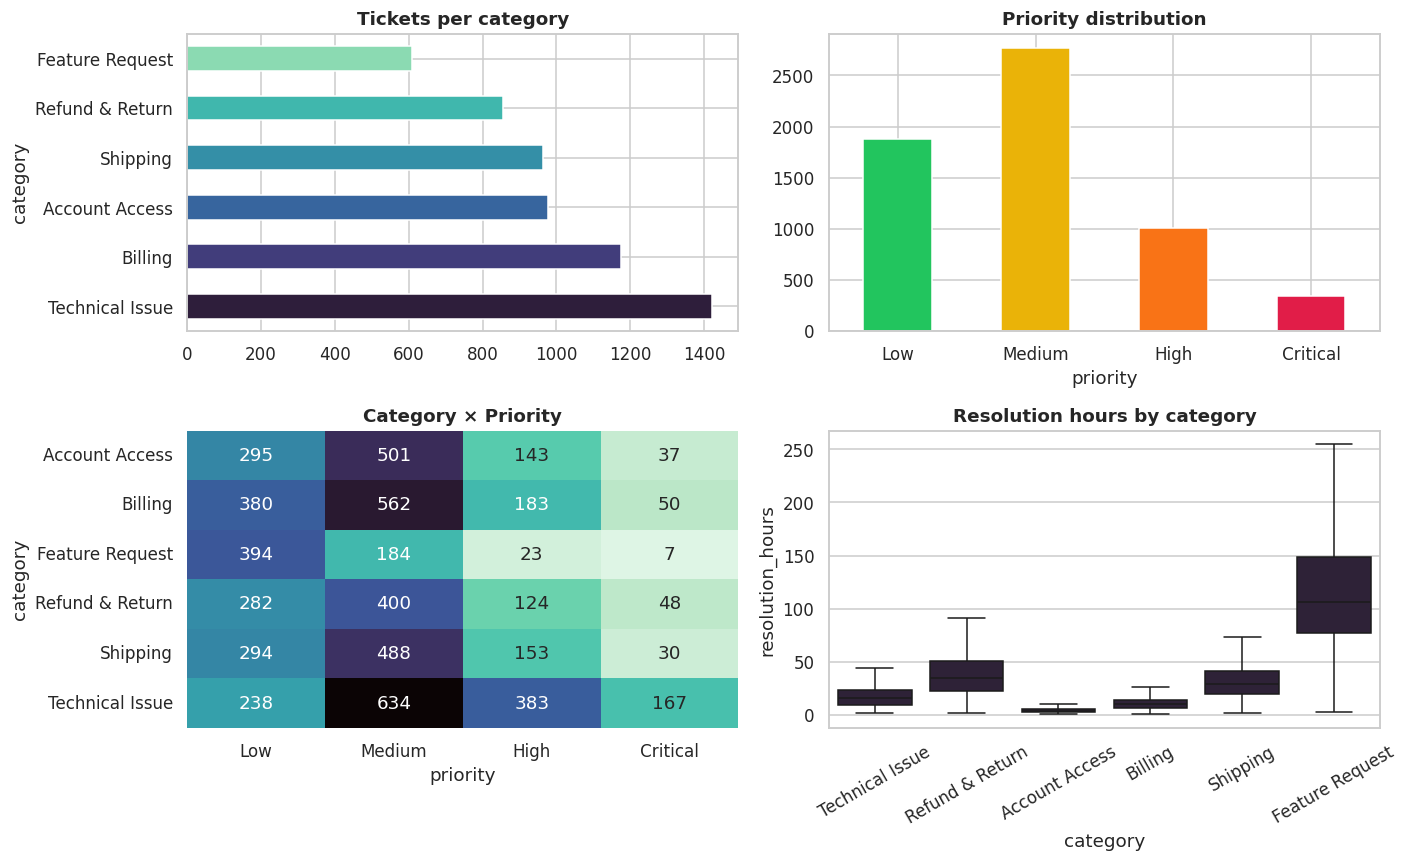

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
order_p = ["Low","Medium","High","Critical"]

df["category"].value_counts().plot.barh(ax=ax[0,0], color=sns.color_palette("mako", 6))
ax[0,0].set_title("Tickets per category")

df["priority"].value_counts().reindex(order_p).plot.bar(ax=ax[0,1], color=["#22c55e","#eab308","#f97316","#e11d48"], rot=0)
ax[0,1].set_title("Priority distribution")

sns.heatmap(pd.crosstab(df["category"], df["priority"])[order_p], annot=True, fmt="d", cmap="mako_r", ax=ax[1,0], cbar=False)
ax[1,0].set_title("Category × Priority")

sns.boxplot(data=df, x="category", y="resolution_hours", ax=ax[1,1], showfliers=False)
ax[1,1].set_title("Resolution hours by category"); ax[1,1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

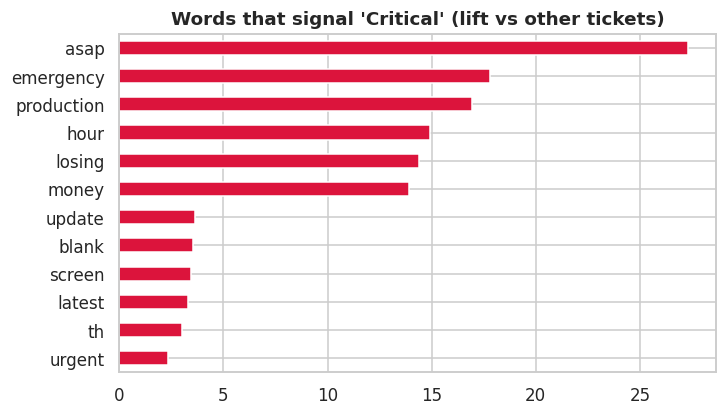

In [5]:
# Does urgent language show up in the text? Words that over-index on Critical tickets:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words="english", min_df=15)
X = cv.fit_transform(df["message"])
crit = np.asarray(X[(df.priority=="Critical").values].mean(0)).ravel()
rest = np.asarray(X[(df.priority!="Critical").values].mean(0)).ravel()
lift = pd.Series((crit+1e-3)/(rest+1e-3), index=cv.get_feature_names_out()).sort_values(ascending=False).head(12)
lift.sort_values().plot.barh(color="crimson", figsize=(7,4), title="Words that signal 'Critical' (lift vs other tickets)")
plt.show()

## 3 · Features
Text is turned into numbers with **TF-IDF on two views at once**:
* **word 1-2-grams** → captures phrases like *"password reset"*
* **character 2-5-grams** → survives typos like *"ther eany"*

The customer tier and channel are one-hot encoded and fed to the priority/time models (an Enterprise customer's outage matters more).

In [6]:
def make_features(use_meta=True):
    text = FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, lowercase=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5), min_df=3, sublinear_tf=True)),
    ])
    transformers = [("text", text, "message")]
    if use_meta:
        transformers.append(("meta", OneHotEncoder(handle_unknown="ignore"), ["customer_tier","channel"]))
    return ColumnTransformer(transformers)

FEATS = ["message","customer_tier","channel"]
X = df[FEATS]
X_tr, X_te, idx_tr, idx_te = train_test_split(X, df.index, test_size=0.2, random_state=SEED, stratify=df["category"])
print("train:", X_tr.shape, " test:", X_te.shape)

train: (4800, 3)  test: (1200, 3)


## 4 · Model 1 — Category (which team should get this?)
race three classic models with 5-fold cross-validation and keep the winner.

Logistic Regression  macro-F1 = 0.962 ± 0.009
Linear SVM           macro-F1 = 0.963 ± 0.010
Complement NB        macro-F1 = 0.963 ± 0.010


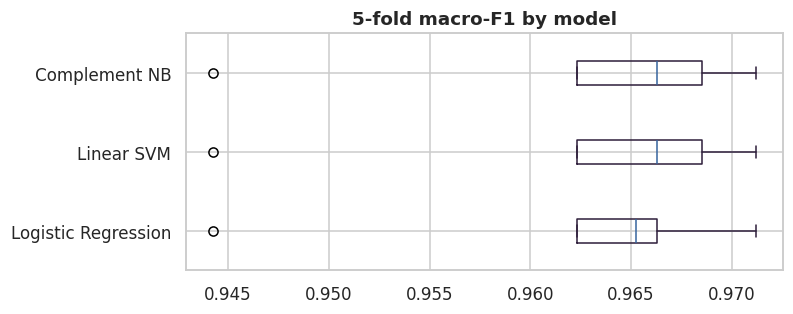

In [7]:
y_cat = df["category"]
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=5),
    "Linear SVM":          LinearSVC(C=0.7),
    "Complement NB":       ComplementNB(alpha=0.3),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
scores = {}
for name, clf in candidates.items():
    pipe = Pipeline([("feat", make_features(use_meta=False)), ("clf", clf)])
    s = cross_val_score(pipe, X_tr, y_cat.loc[idx_tr], cv=cv, scoring="f1_macro", n_jobs=-1)
    scores[name] = s
    print(f"{name:20s} macro-F1 = {s.mean():.3f} ± {s.std():.3f}")

pd.DataFrame(scores).plot.box(vert=False, figsize=(7,2.8), title="5-fold macro-F1 by model"); plt.show()

                 precision    recall  f1-score   support

 Account Access      0.959     0.959     0.959       195
        Billing      0.974     0.962     0.968       235
Feature Request      0.992     0.967     0.979       122
Refund & Return      0.953     0.942     0.947       171
       Shipping      0.950     0.990     0.970       193
Technical Issue      0.982     0.982     0.982       284

       accuracy                          0.968      1200
      macro avg      0.968     0.967     0.968      1200
   weighted avg      0.969     0.968     0.968      1200



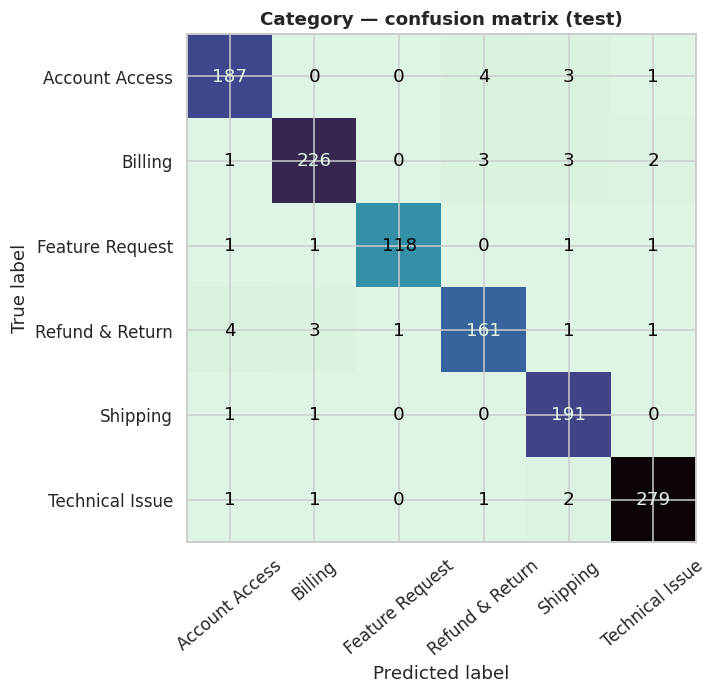

In [8]:
cat_model = Pipeline([("feat", make_features(use_meta=False)),
                      ("clf", LogisticRegression(max_iter=3000, C=5))])   # LR gives calibrated probabilities for the UI
cat_model.fit(X_tr, y_cat.loc[idx_tr])
pred = cat_model.predict(X_te)
print(classification_report(y_cat.loc[idx_te], pred, digits=3))

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(y_cat.loc[idx_te], pred, xticks_rotation=40, cmap="mako_r", colorbar=False, ax=ax)
ax.set_title("Category — confusion matrix (test)"); plt.show()

## 5 · Model 2 — Priority
Priority is **ordinal**, so besides accuracy we also report *within-one-level* accuracy (predicting High for a Critical ticket is a much smaller mistake than predicting Low).

Exact accuracy       : 0.874
Within one level     : 0.935
Macro-F1             : 0.828

              precision    recall  f1-score   support

         Low      0.905     0.887     0.896       388
      Medium      0.951     0.864     0.905       543
        High      0.820     0.868     0.844       205
    Critical      0.527     0.906     0.667        64

    accuracy                          0.874      1200
   macro avg      0.801     0.881     0.828      1200
weighted avg      0.891     0.874     0.879      1200



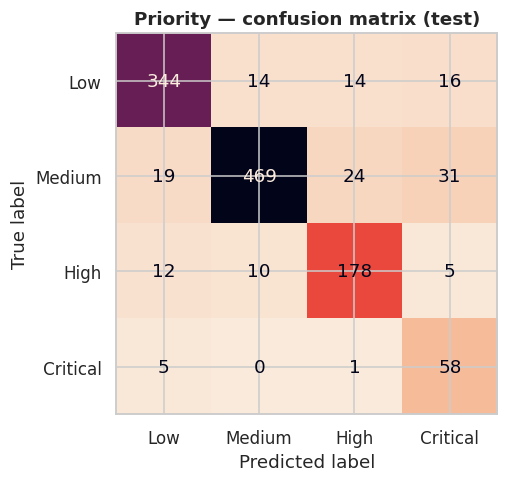

In [9]:
levels = ["Low","Medium","High","Critical"]
y_pri = df["priority"]
pri_model = Pipeline([("feat", make_features()),
                      ("clf", LogisticRegression(max_iter=3000, C=2, class_weight="balanced"))])
pri_model.fit(X_tr, y_pri.loc[idx_tr])
p_pred = pri_model.predict(X_te)

rank = {l:i for i,l in enumerate(levels)}
true_r = y_pri.loc[idx_te].map(rank).values; pred_r = pd.Series(p_pred).map(rank).values
print(f"Exact accuracy       : {accuracy_score(true_r, pred_r):.3f}")
print(f"Within one level     : {(abs(true_r-pred_r)<=1).mean():.3f}")
print(f"Macro-F1             : {f1_score(true_r, pred_r, average='macro'):.3f}\n")
print(classification_report(y_pri.loc[idx_te], p_pred, labels=levels, digits=3))

fig, ax = plt.subplots(figsize=(5.5,4.5))
ConfusionMatrixDisplay.from_predictions(y_pri.loc[idx_te], p_pred, labels=levels, cmap="rocket_r", colorbar=False, ax=ax)
ax.set_title("Priority — confusion matrix (test)"); plt.show()

## 6 · Model 3 — Resolution time
Times are right-skewed, so we regress on `log1p(hours)` and convert back.

MAE  model    :    9.8 h
MAE  baseline :   22.3 h  (always predict the median)
R²   (log-space): 0.821


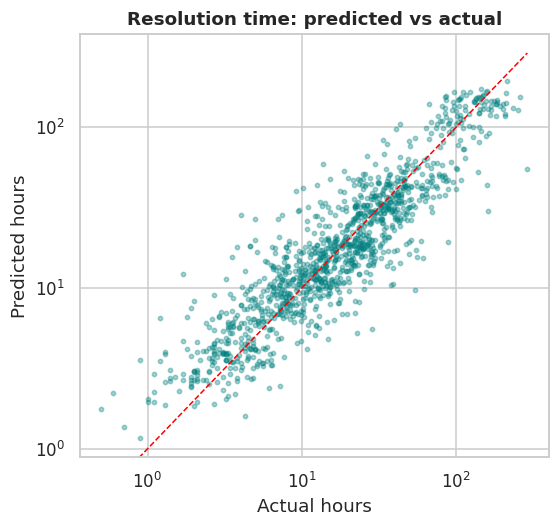

In [10]:
y_time = np.log1p(df["resolution_hours"])
time_model = Pipeline([("feat", make_features()), ("reg", Ridge(alpha=1.0))])
time_model.fit(X_tr, y_time.loc[idx_tr])
t_pred = np.expm1(time_model.predict(X_te)); t_true = df.loc[idx_te, "resolution_hours"].values

baseline = np.full_like(t_true, np.median(df.loc[idx_tr,"resolution_hours"]))
print(f"MAE  model    : {mean_absolute_error(t_true, t_pred):6.1f} h")
print(f"MAE  baseline : {mean_absolute_error(t_true, baseline):6.1f} h  (always predict the median)")
print(f"R²   (log-space): {r2_score(np.log1p(t_true), np.log1p(t_pred)):.3f}")

plt.figure(figsize=(5.5,5)); plt.scatter(t_true, t_pred, s=8, alpha=.35, color="teal")
m = max(t_true.max(), t_pred.max()); plt.plot([0,m],[0,m],"r--", lw=1)
plt.xscale("log"); plt.yscale("log"); plt.xlabel("Actual hours"); plt.ylabel("Predicted hours"); plt.title("Resolution time: predicted vs actual"); plt.show()

## 7 · Open the black box — what did the model learn?
Top words per category, straight from the logistic-regression weights. If these make sense to a human, the model is reasoning on the right signals.

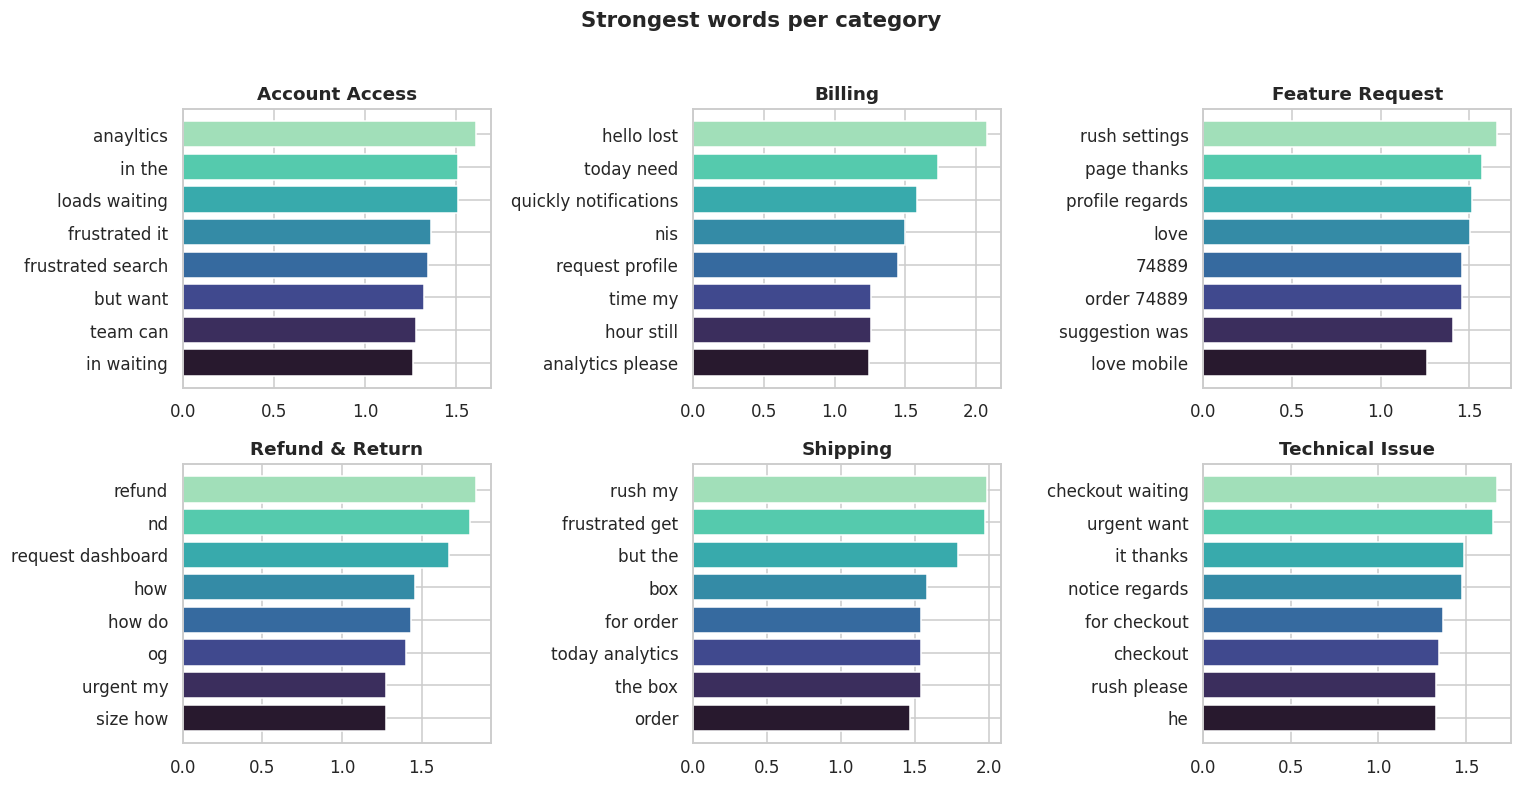

In [11]:
feat = cat_model.named_steps["feat"]; clf = cat_model.named_steps["clf"]
words = feat.named_transformers_["text"].transformer_list[0][1].get_feature_names_out()
n_words = len(words)
coef = clf.coef_[:, :n_words]          # word-level part only (readable)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (i, c) in zip(axes.ravel(), enumerate(clf.classes_)):
    top = np.argsort(coef[i])[-8:]
    ax.barh(words[top], coef[i][top], color=sns.color_palette("mako", 8)); ax.set_title(c)
plt.suptitle("Strongest words per category", y=1.02, fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()

## 8 · The triage engine
One function that takes a raw message and returns a full decision: category, priority, ETA, urgency score, confidence, and the words that drove the decision.

In [12]:
SLA_HOURS = {"Critical":1, "High":4, "Medium":24, "Low":72}
TEAM = {"Billing":"💳 Finance Desk", "Technical Issue":"🛠️ Tech Support", "Account Access":"🔐 Security & Access",
        "Shipping":"📦 Logistics", "Refund & Return":"↩️ Returns Team", "Feature Request":"💡 Product Team"}

def triage(message, tier="Standard", channel="Chat"):
    row = pd.DataFrame([{"message":message, "customer_tier":tier, "channel":channel}])
    c_prob = dict(zip(cat_model.classes_, cat_model.predict_proba(row)[0]))
    p_prob = dict(zip(pri_model.classes_, pri_model.predict_proba(row)[0]))
    category = max(c_prob, key=c_prob.get); priority = max(p_prob, key=p_prob.get)
    eta = float(np.expm1(time_model.predict(row)[0]))
    urgency = sum(p_prob[l]*w for l, w in zip(levels, [0, 33, 66, 100]))          # 0-100 score
    # words that pushed the category decision
    vec = feat.transform(row[["message"]])
    vec = vec.toarray() if hasattr(vec, "toarray") else np.asarray(vec)
    contrib = vec[0, :n_words] * coef[list(clf.classes_).index(category)]     # tf-idf weight × model weight
    top = np.argsort(contrib)[::-1][:4]
    drivers = [words[j] for j in top if contrib[j] > 0]
    return dict(category=category, cat_conf=c_prob[category], cat_probs=c_prob, priority=priority, pri_conf=p_prob[priority],
                pri_probs=p_prob, eta_hours=eta, urgency=urgency, team=TEAM[category], sla=SLA_HOURS[priority], drivers=drivers)

triage("URGENT: payment of ₹4999 deducted twice and my Enterprise plan is still locked, production is down!", tier="Enterprise")

{'category': 'Billing',
 'cat_conf': np.float64(0.6751257909782803),
 'cat_probs': {'Account Access': np.float64(0.022722287141147955),
  'Billing': np.float64(0.6751257909782803),
  'Feature Request': np.float64(0.03420375928758935),
  'Refund & Return': np.float64(0.09010116934347279),
  'Shipping': np.float64(0.04572367887250805),
  'Technical Issue': np.float64(0.13212331437700167)},
 'priority': 'Critical',
 'pri_conf': np.float64(0.9944124935594469),
 'pri_probs': {'Critical': np.float64(0.9944124935594469),
  'High': np.float64(0.002927515970403519),
  'Low': np.float64(0.00195451936688357),
  'Medium': np.float64(0.000705471103265805)},
 'eta_hours': 2.764618274068103,
 'urgency': np.float64(99.6577459563991),
 'team': '💳 Finance Desk',
 'sla': 1,
 'drivers': ['payment', 'of', 'deducted', 'is still']}

## 9 · 🎛️ The interface — Triage Console
Type (or pick) a ticket and hit **Analyse**. You get the routing decision, confidence bars, urgency gauge, SLA and the words behind the decision.

In [13]:
from IPython.display import display, HTML, clear_output

PRI_COLOR = {"Critical":"#e11d48", "High":"#f97316", "Medium":"#eab308", "Low":"#22c55e"}

def _bars(probs, color):
    out = ""
    for k, v in sorted(probs.items(), key=lambda t: -t[1]):
        out += (f"<div style='display:flex;align-items:center;margin:3px 0;font-size:12px'>"
                f"<div style='width:120px'>{k}</div><div style='flex:1;background:#e5e7eb33;border-radius:6px;height:9px'>"
                f"<div style='width:{v*100:.0f}%;background:{color};height:9px;border-radius:6px'></div></div>"
                f"<div style='width:44px;text-align:right'>{v*100:.0f}%</div></div>")
    return out

def render_card(r):
    col = PRI_COLOR[r["priority"]]
    eta = f"{r['eta_hours']:.1f} h" if r["eta_hours"] < 48 else f"{r['eta_hours']/24:.1f} days"
    chips = "".join(f"<span style='background:#6366f122;color:#6366f1;padding:2px 9px;border-radius:99px;margin-right:6px;font-size:12px'>{w}</span>" for w in r["drivers"]) or "—"
    return f"""
    <div style="font-family:system-ui,sans-serif;border:1px solid #6366f155;border-radius:16px;padding:20px;max-width:760px;
                background:linear-gradient(135deg,#6366f111,#06b6d411)">
      <div style="display:flex;gap:12px;flex-wrap:wrap;align-items:center">
        <span style="background:{col};color:white;padding:6px 16px;border-radius:99px;font-weight:700;letter-spacing:.5px">{r['priority'].upper()}</span>
        <span style="font-size:20px;font-weight:700">{r['category']}</span>
        <span style="opacity:.7">→ route to {r['team']}</span>
      </div>
      <div style="display:flex;gap:28px;margin:16px 0;flex-wrap:wrap">
        <div><div style="opacity:.6;font-size:12px">URGENCY SCORE</div><div style="font-size:30px;font-weight:800;color:{col}">{r['urgency']:.0f}<span style="font-size:14px;opacity:.6">/100</span></div></div>
        <div><div style="opacity:.6;font-size:12px">EXPECTED RESOLUTION</div><div style="font-size:30px;font-weight:800">{eta}</div></div>
        <div><div style="opacity:.6;font-size:12px">FIRST-RESPONSE SLA</div><div style="font-size:30px;font-weight:800">{r['sla']} h</div></div>
      </div>
      <div style="display:flex;gap:30px;flex-wrap:wrap">
        <div style="flex:1;min-width:260px"><b>Category confidence</b>{_bars(r['cat_probs'], '#6366f1')}</div>
        <div style="flex:1;min-width:200px"><b>Priority confidence</b>{_bars(r['pri_probs'], col)}</div>
      </div>
      <div style="margin-top:12px"><b>Words that drove the routing:</b> {chips}</div>
    </div>"""

try:
    import ipywidgets as w
    samples = ["— pick a sample —",
        "URGENT: production is down, the checkout page throws error 500 for all our customers!",
        "Hi, I was charged twice for my Pro subscription this month",
        "I lost access to my 2FA device and can't sign in",
        "My order #48211 still hasn't arrived and tracking hasn't updated in 9 days",
        "Not urgent, but it would be great if you added dark mode to the dashboard",
        "i want to retrun my order, wrong size recieved. refund pls"]
    box   = w.Textarea(placeholder="Paste a customer message here…", layout=w.Layout(width="720px", height="90px"))
    pick  = w.Dropdown(options=samples, description="Samples", layout=w.Layout(width="720px"))
    tier  = w.ToggleButtons(options=["Free","Standard","Premium","Enterprise"], value="Standard", description="Tier")
    chan  = w.Dropdown(options=["Email","Chat","Web Form","Phone","Twitter"], value="Chat", description="Channel")
    go    = w.Button(description="⚡ Analyse ticket", button_style="primary", layout=w.Layout(width="200px", height="38px"))
    out   = w.Output()
    pick.observe(lambda c: setattr(box, "value", c["new"]) if c["new"] != samples[0] else None, names="value")
    def on_go(_):
        with out:
            clear_output(wait=True)
            if not box.value.strip(): display(HTML("<i>Type or pick a ticket first.</i>")); return
            display(HTML(render_card(triage(box.value, tier.value, chan.value))))
    go.on_click(on_go)
    display(HTML("<h3 style='font-family:system-ui;margin:0'>🎫 Smart Triage Console</h3>"))
    display(w.VBox([pick, box, w.HBox([tier, chan]), go, out]))
except ImportError:
    print("ipywidgets not installed → run `pip install ipywidgets`. Showing a static example instead:")
    display(HTML(render_card(triage("URGENT: checkout throws error 500 for every customer!", "Enterprise"))))

## 10 · 📋 Live priority queue
Score 12 unseen tickets and sort them the way an agent should work them: highest urgency first.

In [14]:
queue = df.loc[idx_te].sample(12, random_state=3)[["ticket_id","customer_tier","channel","message","category","priority"]].copy()
res = [triage(m, t, c) for m, t, c in zip(queue.message, queue.customer_tier, queue.channel)]
queue["pred_category"] = [r["category"] for r in res]; queue["pred_priority"] = [r["priority"] for r in res]
queue["urgency"] = [round(r["urgency"]) for r in res]; queue["eta_h"] = [round(r["eta_hours"],1) for r in res]
queue = queue.sort_values("urgency", ascending=False).reset_index(drop=True)

def colour(v): return f"background-color:{PRI_COLOR.get(v,'')}33" if v in PRI_COLOR else ""
show = queue[["ticket_id","message","pred_category","pred_priority","urgency","eta_h","priority"]]
try:
    sty = show.style
    sty = (sty.map if hasattr(sty, "map") else sty.applymap)(colour, subset=["pred_priority","priority"])
    sty = sty.bar(subset=["urgency"], color="#f43f5e55", vmin=0, vmax=100)
except Exception:
    sty = show                      # plain table if styling is unavailable
sty

,ticket_id,message,pred_category,pred_priority,urgency,eta_h,priority
0,TKT-100936,I'm losing money every hour. After the latest update the checkout screen is blank Thanks.,Technical Issue,Critical,98,6.700000,Critical
1,TKT-103373,Need this fixed today. The courier marked my parcel delievred but I never received it Please advise.,Shipping,High,61,16.300000,High
2,TKT-101748,I was charged twice for my Pro subscription thsi month,Billing,Medium,36,13.000000,Medium
3,TKT-103903,"Hello, The app keeps crashing every time I open the checkout page Please advise.",Technical Issue,Medium,36,19.900000,Medium
4,TKT-104093,"Hello, My account got locked after several attempts, please unlock it Regards",Account Access,Medium,34,4.400000,Medium
5,TKT-104218,Why did the price of my Premium plan go up without any notice Waiting for your reply.,Billing,Medium,33,8.100000,Low
6,TKT-105883,"I want to return order #71083, the product is not as described Kindly look into it.",Refund & Return,Medium,30,43.700000,Medium
7,TKT-104192,"Whenever you get time, I get an error 500 when I try to use settings",Technical Issue,Low,6,33.600000,Low
8,TKT-100572,"No rush, The payment of ₹7218 was deducted but my Basic plan is still inactive Thanks.",Billing,Low,6,14.900000,Low
9,TKT-103082,Just a suggestion: The payment of ₹8649 was deducted but my Basic plan is still inactive Please advise.,Billing,Low,3,16.800000,Low


## 11 · Save the models
Persist everything so a web app / API can load it later.

In [15]:
joblib.dump({"category":cat_model, "priority":pri_model, "time":time_model}, "ticket_triage_models.joblib")
print("Saved ticket_triage_models.joblib")

Saved ticket_triage_models.joblib


## 12 · 🌐 Launch as a public web app
Turns the triage console into a real web app with a **public link** anyone can open (Gradio `share=True`).
Run all cells above first. The link stays live while this notebook session is running (about 72 hours max).

In [ ]:
!pip install -q gradio

import gradio as gr

EXAMPLES = [
    "URGENT: production is down, the checkout page throws error 500 for all our customers!",
    "Hi, I was charged twice for my Pro subscription this month",
    "I lost access to my 2FA device and can't sign in",
    "My order #48211 still hasn't arrived and tracking hasn't updated in 9 days",
    "Not urgent, but it would be great if you added dark mode to the dashboard",
    "i want to retrun my order, wrong size recieved. refund pls",
]

def run(message, tier, channel):
    if not message.strip():
        return "<i>Type a ticket first.</i>"
    return render_card(triage(message, tier, channel))   # uses the trained models from above

with gr.Blocks(title="Smart Ticket Triage") as demo:
    gr.Markdown("## 🎫 Smart Triage Console")
    msg = gr.Textbox(lines=4, label="Customer message", placeholder="Paste a customer message here…")
    with gr.Row():
        tier = gr.Radio(["Free", "Standard", "Premium", "Enterprise"], value="Standard", label="Tier")
        chan = gr.Dropdown(["Email", "Chat", "Web Form", "Phone", "Twitter"], value="Chat", label="Channel")
    btn = gr.Button("⚡ Analyse ticket", variant="primary")
    out = gr.HTML()
    gr.Examples(EXAMPLES, inputs=msg)
    btn.click(run, [msg, tier, chan], out)

demo.launch(share=True)   # prints a public https://xxxx.gradio.live link